In [1]:
target <- "Survived"
df <-read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/titanic.csv", header=TRUE)
head(df)
colnames(df) # 'Class''Age''Gender''Survived'
df$Survived<-factor(df$Survived) # make success a factor
# -----------------------------------------------------------------------------
# divide into train and test data
set.seed(23)
R=runif(nrow(df)) #create a random uniform column the length of our table
df$R=R #add the random numbers to our table
train<-df[df$R<=.6,] #select roughly 60% for training
test<-df[df$R>.6,] #the other 40% gets placed in test
train<-subset(train,select=-c(R)) #remove the column R
test<-subset(test,select=-c(R)) #remove the column R

,Class,Age,Gender,Survived
,<int>,<dbl>,<chr>,<chr>
1,1,29,F,Yes
2,1,2,F,No
3,1,30,M,No
4,1,25,F,No
5,1,1,M,Yes
6,1,47,M,Yes


[1] "Class"    "Age"      "Gender"   "Survived"

In [2]:
# MAKE A PREDICTION 

# 'Class''Age''Gender''Survived'

predict_data=data.frame(

Class=3, 

Age=18,

Gender="F"

)


Call:
glm(formula = Survived ~ ., family = binomial, data = train)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  5.22072    0.68891   7.578 3.50e-14 ***
Class       -1.36116    0.19352  -7.034 2.01e-12 ***
Age         -0.03567    0.01033  -3.451 0.000558 ***
GenderM     -2.85023    0.27681 -10.297  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 593.78  on 435  degrees of freedom
Residual deviance: 384.45  on 432  degrees of freedom
AIC: 392.45

Number of Fisher Scoring iterations: 5


      model
knownt  no yes
   No  160  31
   Yes  41  88

Warning message:
"package 'pROC' was built under R version 4.5.3"
Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var


Setting levels: control = No, case = Yes

Setting direction: controls < cases



[1] 0.775

[1] 1 2 3

[1] 29.00  2.00 30.00 25.00  1.00 47.00 63.00 39.00 58.00 71.00 19.00 50.00
[13] 24.00 36.00 37.00 26.00 28.00 45.00 22.00 41.00 48.00 44.00 59.00 60.00
[25] 53.00 33.00 14.00 11.00 49.00 46.00 27.00 31.00 64.00 55.00 70.00 69.00
[37] 38.00 17.00  4.00 23.00 35.00 54.00 21.00 52.00 16.00 51.00 42.00 40.00
[49] 15.00 65.00 18.00 56.00 43.00 61.00 13.00 34.00  6.00 57.00 32.00 62.00
[61] 67.00 20.00 12.00  0.83  8.00  7.00  3.00  0.80  9.00  5.00  0.33  0.17
[73] 10.00  1.50

[1] "F" "M"

1 
0.6213372

1 
"survived"

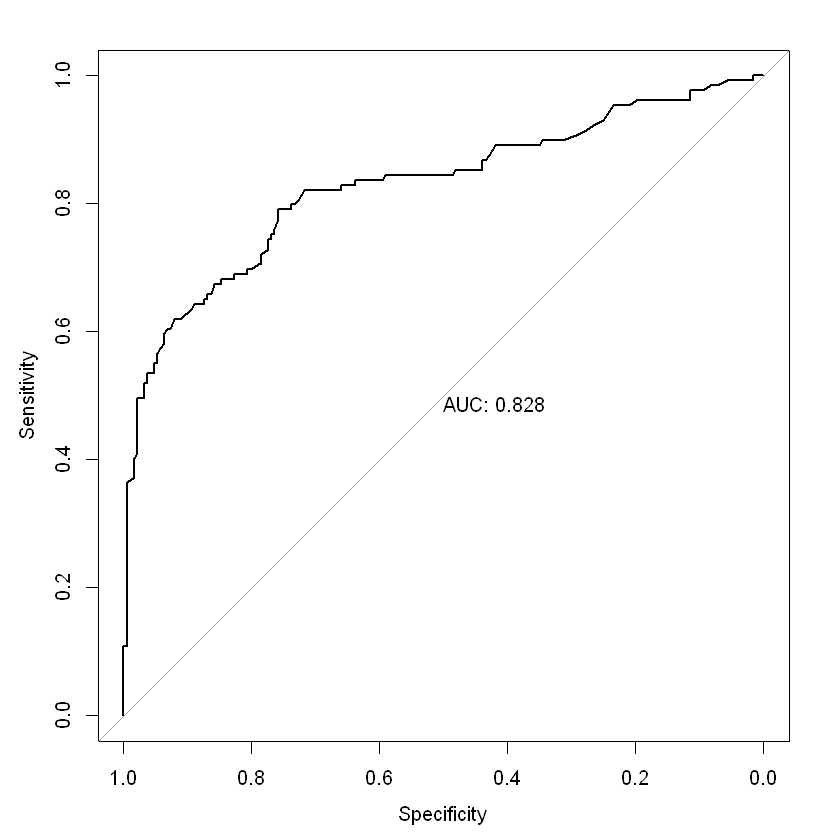

In [3]:
lreg<-glm(Survived~., data=train, family=binomial)

summary(lreg)

pmodel<- predict(lreg,newdata=test, type = "response")

model<- ifelse(pmodel > 0.5, "yes", "no") 

known<-test["Survived"]

knownt<-t(known)

table(knownt,model)

library(pROC)

test_prob = predict(lreg, newdata = test, type = "response")

test_roc = roc(test$Survived ~ test_prob, plot = TRUE, print.auc = TRUE)

# =====================================================================

# ACCURACY OF THE MODEL

n_n <- 160

n_y <- 41

y_n <-31

y_y <- 88

ACCURACY <- (n_n + y_y) / (n_n + n_y + y_n + y_y)

ACCURACY

# =====================================================================

# unique numbers to help with prediction

unique(df$Class)

unique(df$Age)

unique(df$Gender)

# =====================================================================

# MAKE A PREDICTION 

# 'Class''Age''Gender''Survived'

predict(lreg, # logistic regression

predict_data, # prediction dataframe 

type = "response") # greater than .5 they are going to miss 

# =====================================================================

# if else statement to help put a name to the number

ifelse(predict(lreg,

newdata = predict_data, 

type = "response")

>.5, 

"survived", # >.5 going to survive 

"did not survive" # <.5 not going to survive

)

In [4]:
# c1
no_no <- 160
no_yes <- 41
# c2
yes_no <- 31
yes_yes <-88

accuracy_lr <- (no_no + yes_yes) / (no_no + no_yes + yes_no + yes_yes)
round(accuracy_lr,2)
error_rate_lr <- (yes_no + no_yes) / (no_no + no_yes + yes_no + yes_yes)
round(error_rate_lr,2)
true_no_rate_lr <- no_no / (no_no + no_yes)
round(true_no_rate_lr,2)
true_yes_rate_lr <- yes_yes / (yes_no + yes_yes)
round(true_yes_rate_lr,2)

[1] 0.78

[1] 0.22

[1] 0.8

[1] 0.74

Warning message:
"package 'rpart' was built under R version 4.5.3"
Warning message:
"package 'rpart.plot' was built under R version 4.5.3"


      model
knownt  No Yes
   No  166  25
   Yes  43  86

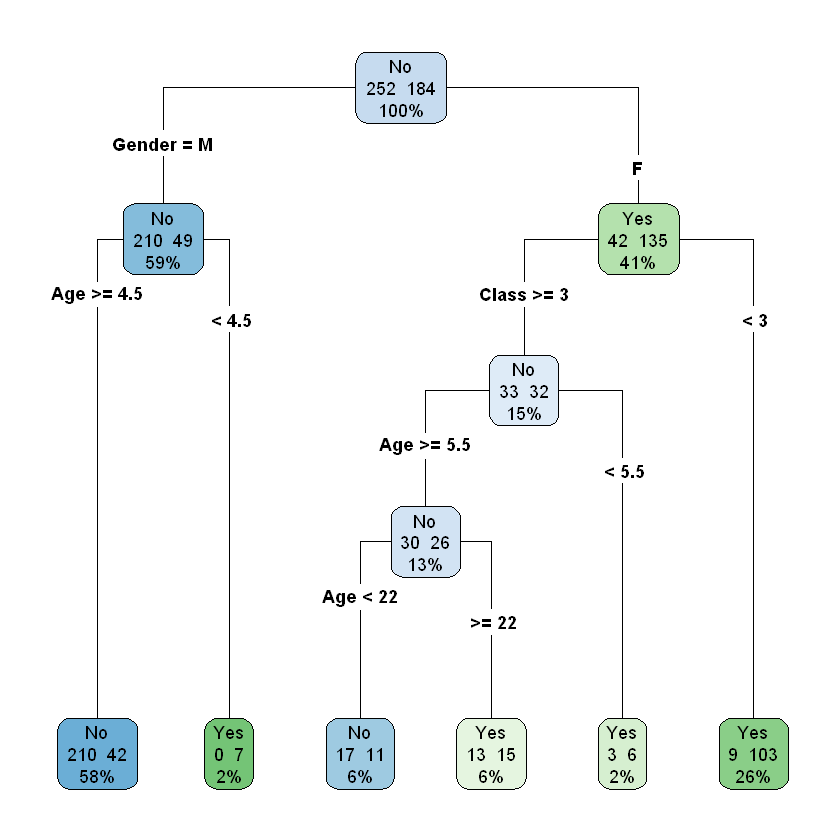

In [5]:
# class tree
#install.packages('rpart', dependencies = TRUE)
#install.packages('rpart.plot', dependencies = TRUE)
library(rpart)
library(rpart.plot)
#can’t use success~. due to extra columns in train:
ctree<-rpart(Survived~.,data=train)
#summary(ctree)
#plot the tree, type=4 labels splits and the nodes, extra=101 adds extra calculations in each node
rpart.plot(ctree, type = 4, extra = 101)

# fit the model to the testing data
model<- predict(ctree, newdata=test, type = "class")
known<-test[target] #extract the actual value of success for comparing
knownt<-t(known) #transpose the data for the confusion matrix
table(knownt,model) #create the confusion matrix

In [6]:
# interpreting the output CLASS TREE
# c1
no_no <- 166
no_yes <- 43
# c2
yes_no <- 25
yes_yes <-86

accuracy_tree <- (no_no + yes_yes) / (no_no + no_yes + yes_no + yes_yes)
round(accuracy_tree,2)
error_rate_tree <- (yes_no + no_yes) / (no_no + no_yes + yes_no + yes_yes)
round(error_rate_tree,2)
true_no_rate_tree <- no_no / (no_no + no_yes)
round(true_no_rate_tree,2)
true_yes_rate_tree <- yes_yes / (yes_no + yes_yes)
round(true_yes_rate_tree,2)

[1] 0.79

[1] 0.21

[1] 0.79

[1] 0.77

In [7]:
#predict with the classification tree
predict(ctree,newdata=predict_data,type="class")

1 
No 
Levels: No Yes

In [8]:
# random forrest
library(randomForest)
set.seed(23) #needed to make the RF repeatable
RFM=randomForest(Survived~.,data=train)
#summary(RFM)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.



In [9]:
# fit model to testing data
model<- predict(RFM, newdata=test, type = "class")
known<-test[target] #extract the actual value of success for comparing
knownt<-t(known) #transpose the data for the confusion matrix
table(knownt,model) #create the confusion matrix

      model
knownt  No Yes
   No  185   6
   Yes  53  76

In [10]:
# fine tune the model
set.seed(23)
RFM=randomForest(Survived~.,data=train,
mtry=4,ntrees=1000)
model<- predict(RFM, newdata=test, type = "class")
known<-test[target] #extract the actual value of success for comparing
knownt<-t(known) #transpose the data for the confusion matrix
table(knownt,model) #create the confusion matrix

Warning message in randomForest.default(m, y, ...):
"invalid mtry: reset to within valid range"


      model
knownt  No Yes
   No  151  40
   Yes  36  93

In [11]:
# interpreting the output random forrest
# c1
no_no <- 151
no_yes <- 36
# c2
yes_no <- 40
yes_yes <- 93

accuracy_rf <- (no_no + yes_yes) / (no_no + no_yes + yes_no + yes_yes)
round(accuracy_rf,2)
error_rate_rf <- (yes_no + no_yes) / (no_no + no_yes + yes_no + yes_yes)
round(error_rate_rf,2)
true_no_rate_rf <- no_no / (no_no + no_yes)
round(true_no_rate_rf,2)
true_yes_rate_rf <- yes_yes / (yes_no + yes_yes)
round(true_yes_rate_rf,2)

[1] 0.76

[1] 0.24

[1] 0.81

[1] 0.7

In [12]:
# predict w/ rf
predict(RFM, newdata = predict_data, type = "class")

1 
Yes 
Levels: No Yes

In [13]:
# ann
#install.packages("nnet")
library(nnet)
set.seed(17)
ANN<-nnet(Survived~.,data=train, size=4)

Warning message:
"package 'nnet' was built under R version 4.5.3"


# weights:  21
initial  value 330.696691 
iter  10 value 286.095309
iter  20 value 189.999484
iter  30 value 177.278432
iter  40 value 176.349878
iter  50 value 176.013308
iter  60 value 175.956774
iter  70 value 175.793046
iter  80 value 174.931615
iter  90 value 174.381300
iter 100 value 174.368998
final  value 174.368998 
stopped after 100 iterations


In [14]:
model<- predict(ANN, newdata=test, type = "class")
known<-test[target] #extract the actual value of success for comparing
knownt<-t(known) #transpose the data for the confusion matrix
table(knownt,model) #create the confusion matrix

      model
knownt  No Yes
   No  169  22
   Yes  42  87

In [15]:
# interpret the model
# c1
no_no <- 169
no_yes <- 42
# c2
yes_no <- 22
yes_yes <- 87

accuracy_ann <- (no_no + yes_yes) / (no_no + no_yes + yes_no + yes_yes)
round(accuracy_ann,2)
error_rate_ann <- (yes_no + no_yes) / (no_no + no_yes + yes_no + yes_yes)
round(error_rate_ann,2)
true_no_rate_ann <- no_no / (no_no + no_yes)
round(true_no_rate_ann,2)
true_yes_rate_ann <- yes_yes / (yes_no + yes_yes)
round(true_yes_rate_ann,2)

[1] 0.8

[1] 0.2

[1] 0.8

[1] 0.8

In [16]:
# ann prediction
predict(ANN,newdata=predict_data, type="class")

[1] "No"

In [18]:
cat("ACCURACY: ", "rf ", round(accuracy_rf,2), 
    " tree ", round(accuracy_tree,2),
    " ann ", round(accuracy_ann,2),
    "lr ", round(accuracy_lr,2))

accuracies <- c(
    "Random Forest" = accuracy_rf,
    "Decision Tree" = accuracy_tree,
    "ANN" = accuracy_ann,
    "Log Regression" = accuracy_lr
)

best_model <- names(which.max(accuracies))
print(best_model)

ACCURACY:  rf  0.76  tree  0.79  ann  0.8 lr  0.78[1] "ANN"


# What I did 
I created a random forest, decision tree, artificial nueral network, and a logistic regression to predict if someone would survie the titanic. The Classification Tree got the best results with an accuracy of .82. For this reason the best model to predict survival in this dataset would be Classification Tree. ACCURACY:  rf  0.76  tree  0.79  ann  0.8 lr  0.78[1] "ANN"
Predictions: 
# If you were in class 3, Age = 18, and were a female
## Logistic Regression: Survived
## Classification Tree: Die
## Random Forest: Survive
## ANN: Die

ACCURACY:  rf  0.76  tree  0.79  ann  0.8 lr  0.78[1] "ANN"